Loading datasets...
Datasets loaded successfully!

Cleaning data...
Boston Data Shape: (506, 19)
King County Cleaned Shape: (437, 9)

Generating visualizations...


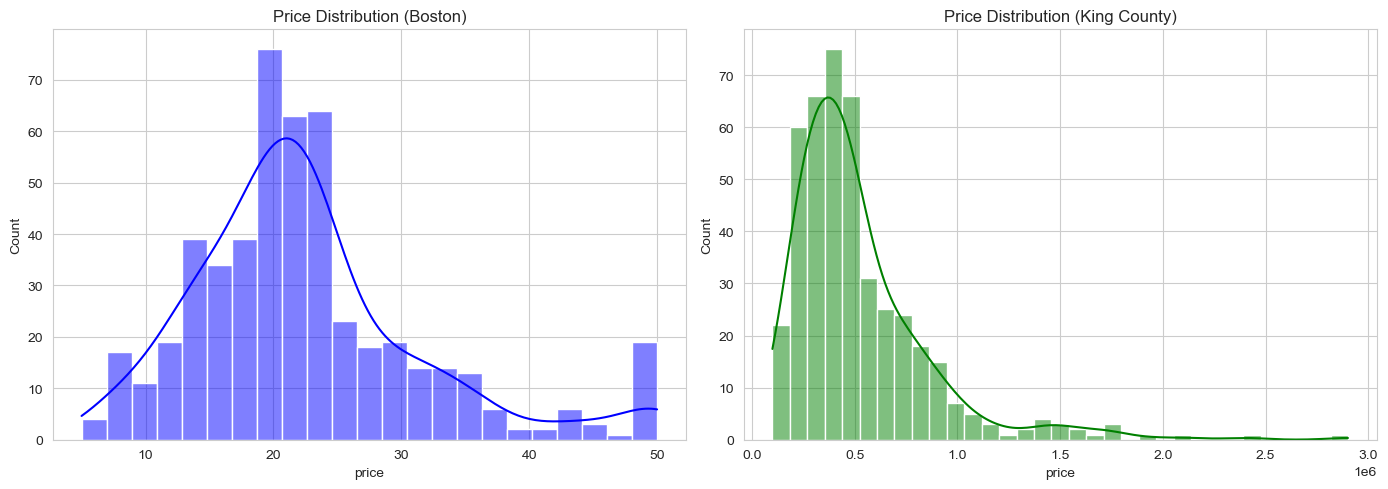

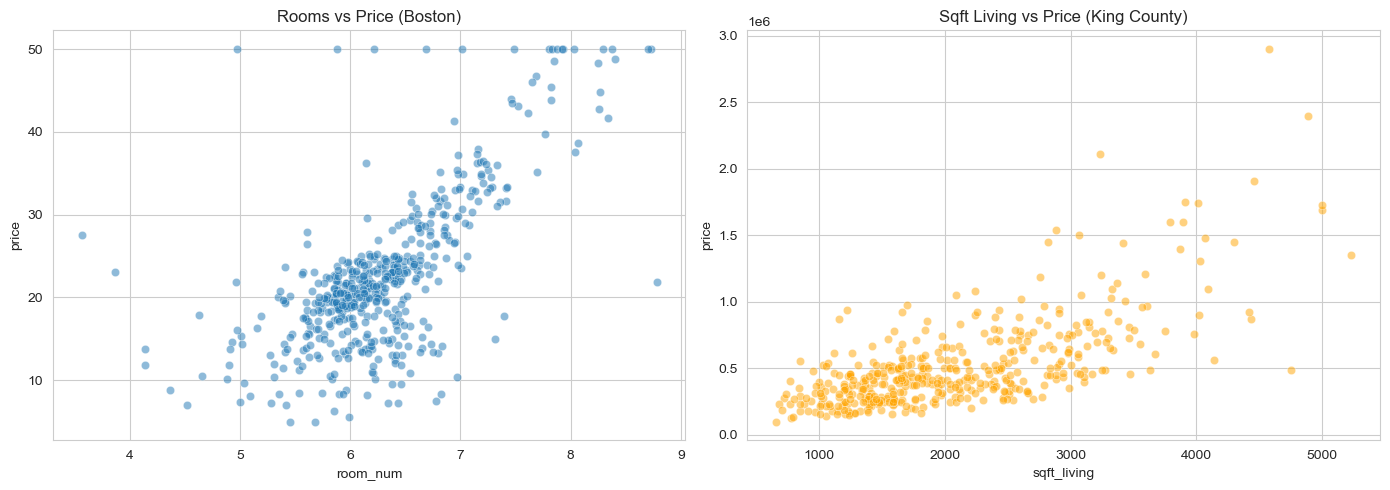

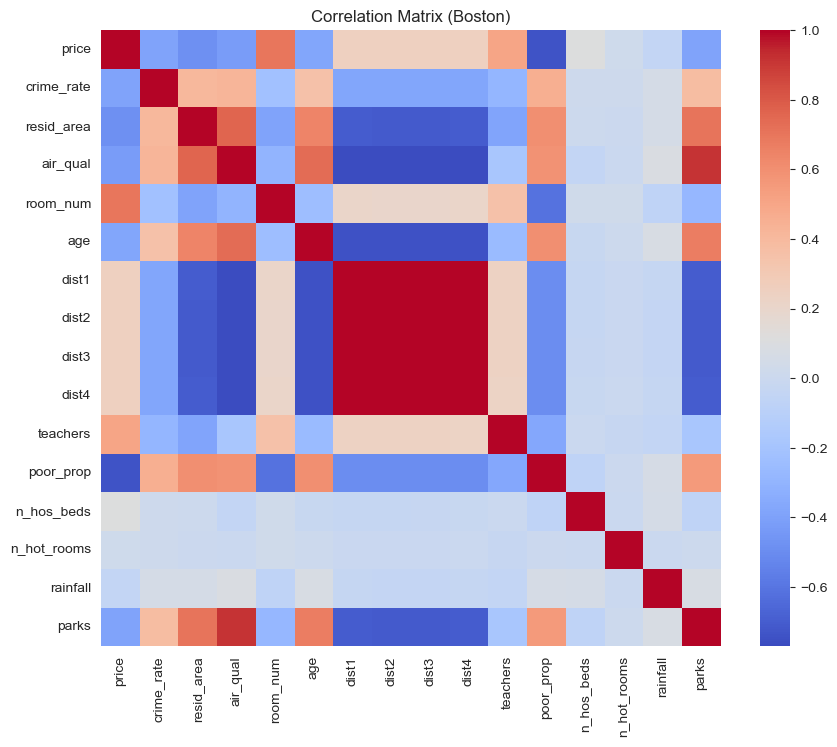


Training models...

--- Results for King County ---
Linear Regression -> R2: 0.5095, MAE: 148676.61
Random Forest -> R2: 0.5249, MAE: 145995.59


/var/folders/l8/mlkxts6n1ql7dz896cjkn_x80000gn/T/ipykernel_1897/2240348018.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[kc_cols[i] for i in indices], palette='viridis')


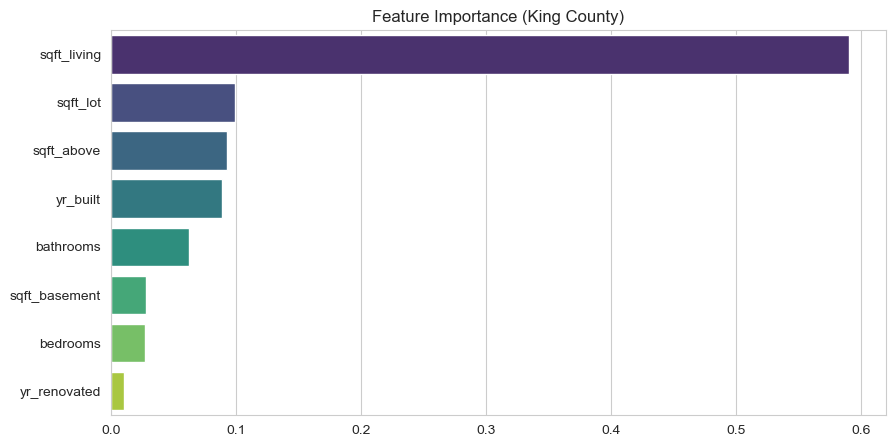


--- Results for Boston Housing ---
Linear Regression -> R2: 0.6245, MAE: 3.43


/var/folders/l8/mlkxts6n1ql7dz896cjkn_x80000gn/T/ipykernel_1897/2240348018.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_hp[indices_hp], y=[hp_cols[i] for i in indices_hp], palette='magma')


Random Forest -> R2: 0.8101, MAE: 2.12


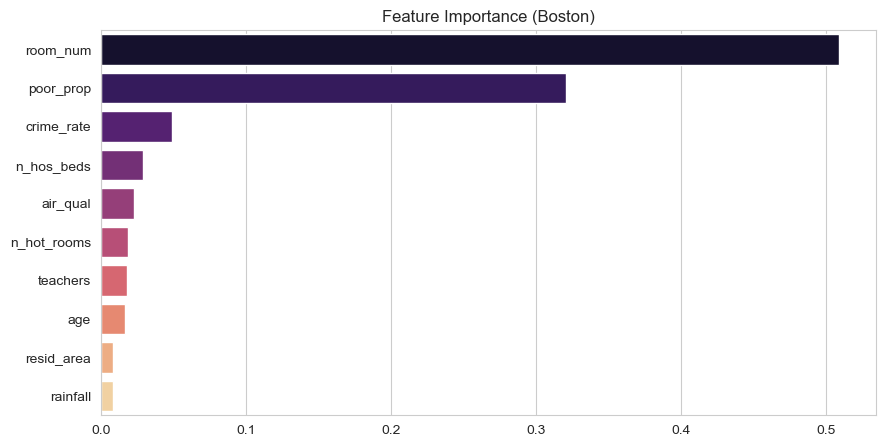

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import os

# ==========================================
# 1. LOAD DATASETS (WITH DEBUGGING)
# ==========================================
print("Loading datasets...")

# Define file names
file_kc = "KC_BL_DATASET.csv"
file_hp = "House_Price.csv"

# Check if files exist before trying to read them
if not os.path.exists(file_kc) or not os.path.exists(file_hp):
    print("\n[ERROR] FILES NOT FOUND!")
    print(f"I am looking for files in this folder: {os.getcwd()}")
    print("Files found in this folder:", os.listdir(os.getcwd()))
    print("\nSOLUTION: Please move 'KC_BL_DATASET.csv' and 'House_Price.csv' into the folder printed above.")
    
    # Stop execution here to prevent the NameError crash
    raise FileNotFoundError("Stopping script because data files are missing.")

# If files exist, load them
house_prices = pd.read_csv(file_hp)
kc_data = pd.read_csv(file_kc)
print("Datasets loaded successfully!")


# ==========================================
# 2. DATA CLEANING & PREPROCESSING
# ==========================================
print("\nCleaning data...")

# --- A. Clean Boston House Price Data ---
house_prices.fillna(house_prices.mean(numeric_only=True), inplace=True)
house_prices.drop_duplicates(inplace=True)

# --- B. Clean King County Data ---
# Potential columns to keep (Housing only)
potential_kc_cols = [
    'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 
    'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 
    'floors', 'lat', 'long' 
]
# Keep only columns that actually exist in your file
existing_kc_cols = [col for col in potential_kc_cols if col in kc_data.columns]
kc_clean = kc_data[existing_kc_cols].copy()

# Drop rows with missing values
kc_clean.dropna(inplace=True)

print(f"Boston Data Shape: {house_prices.shape}")
print(f"King County Cleaned Shape: {kc_clean.shape}")

# ==========================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("\nGenerating visualizations...")
sns.set_style("whitegrid")

# --- A. Price Distribution Comparison ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(house_prices['price'], kde=True, ax=ax[0], color='blue')
ax[0].set_title('Price Distribution (Boston)')

sns.histplot(kc_clean['price'], kde=True, ax=ax[1], color='green')
ax[1].set_title('Price Distribution (King County)')
plt.tight_layout()
plt.show()

# --- B. Feature vs Price (Scatter) ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='room_num', y='price', data=house_prices, ax=ax[0], alpha=0.5)
ax[0].set_title('Rooms vs Price (Boston)')

if 'sqft_living' in kc_clean.columns:
    sns.scatterplot(x='sqft_living', y='price', data=kc_clean, ax=ax[1], color='orange', alpha=0.5)
    ax[1].set_title('Sqft Living vs Price (King County)')
plt.tight_layout()
plt.show()

# --- C. Correlation Matrix ---
plt.figure(figsize=(10, 8))
sns.heatmap(house_prices.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix (Boston)")
plt.show()

# ==========================================
# 4. MACHINE LEARNING PIPELINE
# ==========================================
print("\nTraining models...")

def train_and_evaluate(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
    }
    
    print(f"\n--- Results for {name} ---")
    results = {}
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        
        print(f"{model_name} -> R2: {r2:.4f}, MAE: {mae:.2f}")
        results[model_name] = model
        
    return results, X_train.columns

# --- Run for King County ---
kc_features = [c for c in existing_kc_cols if c != 'price']
if kc_features:
    kc_models, kc_cols = train_and_evaluate(kc_clean[kc_features], kc_clean['price'], "King County")
    
    # Feature Importance
    importances = kc_models["Random Forest"].feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=importances[indices], y=[kc_cols[i] for i in indices], palette='viridis')
    plt.title("Feature Importance (King County)")
    plt.show()

# --- Run for Boston ---
hp_features = ['crime_rate', 'resid_area', 'air_qual', 'room_num', 'age', 'teachers', 'poor_prop', 'n_hos_beds', 'n_hot_rooms', 'rainfall']
hp_features = [c for c in hp_features if c in house_prices.columns]

hp_models, hp_cols = train_and_evaluate(house_prices[hp_features], house_prices['price'], "Boston Housing")

# Feature Importance
importances_hp = hp_models["Random Forest"].feature_importances_
indices_hp = np.argsort(importances_hp)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances_hp[indices_hp], y=[hp_cols[i] for i in indices_hp], palette='magma')
plt.title("Feature Importance (Boston)")
plt.show()